In [ ]:
!pip install gymnasium stable-baselines3 numpy

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv


def wrap_pi(angle):
    """Wrap angle to (-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


class UnicycleTargetEnv(gym.Env):
    """
    Unicycle kinematics:
        x_dot = v cos(theta)
        y_dot = v sin(theta)
        theta_dot = omega

    Action: omega (angular velocity)
    Observation: [dx, dy, cos(theta), sin(theta), cos(phi), sin(phi), dist, heading_error]
      where phi = angle to target
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        dt=0.1,
        v=1.0,
        omega_max=2.5,
        world_size=10.0,
        target_radius=0.25,
        max_steps=300,
        seed=None,
    ):
        super().__init__()
        self.dt = float(dt)
        self.v = float(v)
        self.omega_max = float(omega_max)
        self.world_size = float(world_size)
        self.target_radius = float(target_radius)
        self.max_steps = int(max_steps)

        self.np_random = np.random.default_rng(seed)

        # Action: omega in [-omega_max, omega_max]
        self.action_space = spaces.Box(
            low=np.array([-self.omega_max], dtype=np.float32),
            high=np.array([ self.omega_max], dtype=np.float32),
            dtype=np.float32,
        )

        # Observation:
        # dx, dy in [-2*world_size, 2*world_size]
        # cos/sin in [-1, 1], dist in [0, ~2*sqrt(2)*world_size], heading_error in [-pi, pi]
        obs_low = np.array(
            [-2*self.world_size, -2*self.world_size, -1, -1, -1, -1, 0.0, -np.pi],
            dtype=np.float32,
        )
        obs_high = np.array(
            [ 2*self.world_size,  2*self.world_size,  1,  1,  1,  1, 2*np.sqrt(2)*self.world_size, np.pi],
            dtype=np.float32,
        )
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

        self.x = None
        self.y = None
        self.theta = None
        self.tx = None
        self.ty = None
        self.steps = 0
        self.prev_dist = None

    def _get_obs(self):
        dx = self.tx - self.x
        dy = self.ty - self.y
        dist = np.sqrt(dx*dx + dy*dy)

        phi = np.arctan2(dy, dx)                  # bearing to target
        heading_error = wrap_pi(phi - self.theta) # error angle

        obs = np.array(
            [
                dx,
                dy,
                np.cos(self.theta),
                np.sin(self.theta),
                np.cos(phi),
                np.sin(phi),
                dist,
                heading_error,
            ],
            dtype=np.float32,
        )
        return obs

    def reset(
            self,
            seed=None,
            options=None,
            start=None,     # (x, y)
            target=None,    # (tx, ty)
            theta0=None     # initial heading
        ):
            super().reset(seed=seed)

            # ---- RNG handling (unchanged) ----
            if seed is not None:
                self.np_random = np.random.default_rng(seed)

            # ---- Start position ----
            if start is not None:
                self.x, self.y = start
            else:
                self.x = self.np_random.uniform(-self.world_size, self.world_size)
                self.y = self.np_random.uniform(-self.world_size, self.world_size)

            # ---- Initial heading ----
            if theta0 is not None:
                self.theta = theta0
            else:
                self.theta = self.np_random.uniform(-np.pi, np.pi)

            # ---- Target position ----
            if target is not None:
                self.tx, self.ty = target
            else:
                # Sample target until not too close (UNCHANGED LOGIC)
                for _ in range(100):
                    self.tx = self.np_random.uniform(-self.world_size, self.world_size)
                    self.ty = self.np_random.uniform(-self.world_size, self.world_size)
                    if (self.tx - self.x)**2 + (self.ty - self.y)**2 > (0.5*self.world_size)**2:
                        break

            # ---- Episode bookkeeping (IMPORTANT: unchanged) ----
            self.steps = 0
            obs = self._get_obs()
            self.prev_dist = float(obs[6])  # distance index preserved
            info = {}

            return obs, info

    def step(self, action):
        self.steps += 1

        omega = float(np.clip(action[0], -self.omega_max, self.omega_max))

        # --- KINEMATICS UPDATE ---
        # x_{t+1} = x_t + dt * v cos(theta)
        # y_{t+1} = y_t + dt * v sin(theta)
        # theta_{t+1} = theta_t + dt * omega
        self.x += self.dt * self.v * np.cos(self.theta)
        self.y += self.dt * self.v * np.sin(self.theta)
        self.theta = wrap_pi(self.theta + self.dt * omega)

        obs = self._get_obs()
        dist = float(obs[6])
        heading_error = float(obs[7])

        # --- REWARD SHAPING ---
        # 1) progress reward: distance reduction
        progress = self.prev_dist - dist

        # 2) small penalty for being misaligned (encourages turning toward target)
        align_penalty = 0.05 * abs(heading_error)

        # 3) small action penalty (smooth control)
        control_penalty = 0.01 * (omega / self.omega_max) ** 2

        reward = 5.0 * progress - align_penalty - control_penalty

        terminated = dist <= self.target_radius
        truncated = self.steps >= self.max_steps

        # success bonus
        if terminated:
            reward += 10.0

        self.prev_dist = dist
        info = {"dist": dist, "heading_error": heading_error, "omega": omega}
        return obs, reward, terminated, truncated, info


def train():
    env = UnicycleTargetEnv(
        dt=0.1,
        v=1.0,
        omega_max=3.0,
        world_size=10.0,
        target_radius=0.3,
        max_steps=300,
        seed=0,
    )

    # Sanity check
    check_env(env, warn=True)

    # SB3 needs vectorized env
    vec_env = DummyVecEnv([lambda: env])

    model = PPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        n_steps=2048,
        batch_size=256,
        gamma=0.99,
        gae_lambda=0.95,
        learning_rate=3e-4,
        ent_coef=0.0,
        clip_range=0.2,
        device="auto",
    )

    model.learn(total_timesteps=300_000)
    model.save("ppo_unicycle_target")
    print("Saved model to ppo_unicycle_target.zip")


def test(episodes=5):
    env = UnicycleTargetEnv(seed=123)
    model = PPO.load("ppo_unicycle_target")

    for ep in range(episodes):
        obs, _ = env.reset()
        total_r = 0.0
        for t in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            if term or trunc:
                print(f"Episode {ep}: steps={t+1}, success={term}, dist={info['dist']:.3f}, return={total_r:.2f}")
                break


if __name__ == "__main__":
    train()
    test()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:507: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1405 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 1245        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005713664 |
|    clip_fraction        | 0.0391      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.41       |
|    explained_variance   | 0.00647     |
|    learning_rate        | 0.0003      |
|    loss                 | 9.4         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00544    |
|    std                  | 0.988       |
|    value_loss           | 31.2        |
-----------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1209         |
|    iterations           | 3            |
|    time_elapsed         | 5 

Episode 1: Steps=82, Success=True, Final Distance=0.214, Return=49.89


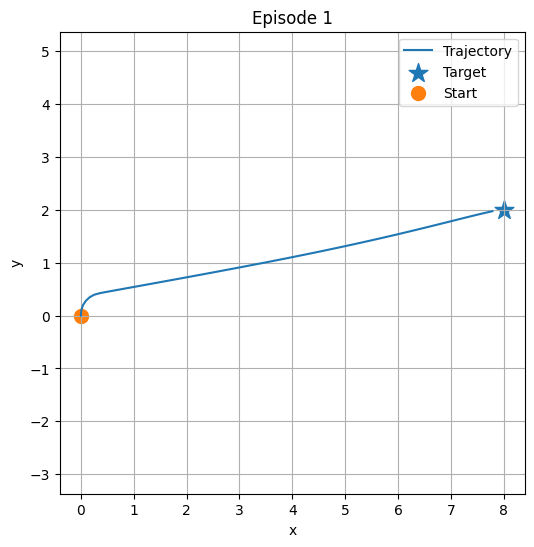

Episode 2: Steps=82, Success=True, Final Distance=0.214, Return=49.89


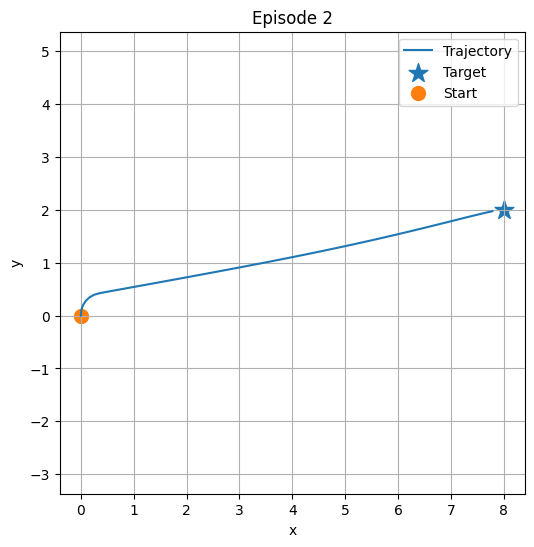

Episode 3: Steps=82, Success=True, Final Distance=0.214, Return=49.89


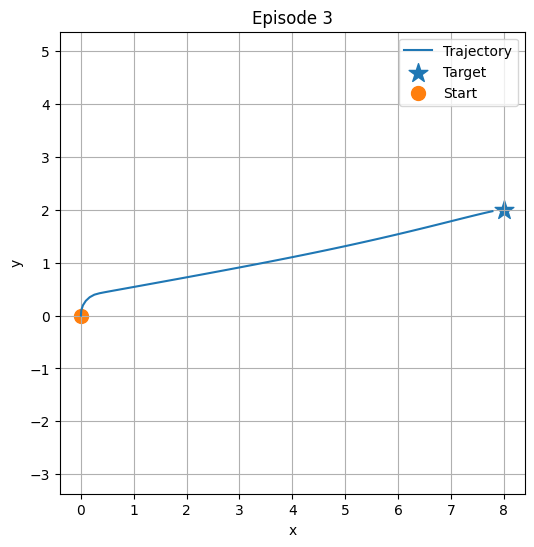

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
#from unicycle_target_rl import UnicycleTargetEnv  # make sure same file is accessible


def run_test(model_path="ppo_unicycle_target.zip", episodes=3):
    model = PPO.load(model_path)
    env = UnicycleTargetEnv(seed=42)

    for ep in range(episodes):
        obs, _ = env.reset(
          start=(0.0, 0.0),
          target=(8.0, 2.0),
          theta0=1.5
          )

        xs, ys = [env.x], [env.y]
        total_reward = 0

        for step in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            xs.append(env.x)
            ys.append(env.y)
            total_reward += reward

            if terminated or truncated:
                break

        print(
            f"Episode {ep+1}: "
            f"Steps={step+1}, "
            f"Success={terminated}, "
            f"Final Distance={info['dist']:.3f}, "
            f"Return={total_reward:.2f}"
        )

        # -------- Plot trajectory --------
        plt.figure(figsize=(6,6))
        plt.plot(xs, ys, label="Trajectory")
        plt.scatter(env.tx, env.ty, marker="*", s=200, label="Target")
        plt.scatter(xs[0], ys[0], marker="o", s=100, label="Start")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"Episode {ep+1}")
        plt.legend()
        plt.axis("equal")
        plt.grid()
        plt.show()


if __name__ == "__main__":
    run_test()